In [1]:
# ============================================================================
# ЛАБОРАТОРНАЯ РАБОТА №4: МЕТОДЫ УСЛОВНОЙ ОПТИМИЗАЦИИ
# LABORATORY WORK #4: CONSTRAINED OPTIMIZATION METHODS
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize

%matplotlib inline

# Настройка графиков / Plot settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("БИБЛИОТЕКИ УСПЕШНО ЗАГРУЖЕНЫ")
print("All libraries loaded successfully")
print("=" * 60)

# ============================================================================
# ПАРАМЕТРЫ ВАРИАНТА №4 / VARIANT №4 PARAMETERS
# ============================================================================

a = 250      # коэффициент a
b = 2        # коэффициент b
f0 = 50      # константа f0
n = 2        # размерность задачи

print(f"\nПараметры варианта №4 / Variant №4 parameters:")
print(f"  a = {a}")
print(f"  b = {b}")
print(f"  f0 = {f0}")
print(f"  n = {n}")

# ============================================================================
# ФУНКЦИЯ РОЗЕНБРОКА И ЕЁ ГРАДИЕНТ / ROSENBROCK FUNCTION AND GRADIENT
# ============================================================================

def rosenbrock(x):
    """
    Функция Розенброка / Rosenbrock function
    f(x) = a*(x1^2 - x2)^2 + b*(x1 - 1)^2 + f0
    """
    x = np.asarray(x)
    return a * (x[0]**2 - x[1])**2 + b * (x[0] - 1)**2 + f0


def rosenbrock_gradient(x):
    """
    Градиент функции Розенброка / Gradient of Rosenbrock function
    df/dx1 = 4*a*x1*(x1^2 - x2) + 2*b*(x1 - 1)
    df/dx2 = -2*a*(x1^2 - x2)
    """
    x = np.asarray(x)
    grad = np.zeros(2)
    grad[0] = 4 * a * x[0] * (x[0]**2 - x[1]) + 2 * b * (x[0] - 1)
    grad[1] = -2 * a * (x[0]**2 - x[1])
    return grad


# ============================================================================
# ОГРАНИЧЕНИЯ / CONSTRAINTS
# ============================================================================

def g1(x):
    """Первое ограничение / First constraint: x1^2 + x2^2 - 80 <= 0"""
    return x[0]**2 + x[1]**2 - 80


def g2(x):
    """Второе ограничение / Second constraint: -x1 <= 0 (x1 >= 0)"""
    return -x[0]


def g3(x):
    """Третье ограничение / Third constraint: -x2 <= 0 (x2 >= 0)"""
    return -x[1]


def constraints(x):
    """Все ограничения / All constraints"""
    return [g1(x), g2(x), g3(x)]


def check_feasibility(x):
    """
    Проверка принадлежности точки допустимому множеству
    Check if point is feasible
    """
    constraints_values = constraints(x)
    is_feasible = all(c <= 1e-8 for c in constraints_values)
    return is_feasible, constraints_values


# ============================================================================
# ТЕСТИРОВАНИЕ ФУНКЦИИ И ОГРАНИЧЕНИЙ
# ============================================================================

print("\n" + "-" * 60)
print("ТЕСТИРОВАНИЕ ФУНКЦИИ И ОГРАНИЧЕНИЙ")
print("FUNCTION AND CONSTRAINTS TESTING")
print("-" * 60)

# Точка минимума / Minimum point
x_min = np.array([1.0, 1.0])
f_min = rosenbrock(x_min)
grad_min = rosenbrock_gradient(x_min)

print(f"\nТочка минимума / Minimum point: x = {x_min}")
print(f"Значение функции / Function value: f(x) = {f_min}")
print(f"Градиент / Gradient: {grad_min}")

# Проверка ограничений в точке минимума
feasible, constr_vals = check_feasibility(x_min)
print(f"\nПроверка ограничений в точке x = {x_min}:")
print(f"  g1(x) = x1^2 + x2^2 - 80 = {constr_vals[0]:.2f} <= 0? {constr_vals[0] <= 0}")
print(f"  g2(x) = -x1 = {constr_vals[1]:.2f} <= 0? {constr_vals[1] <= 0}")
print(f"  g3(x) = -x2 = {constr_vals[2]:.2f} <= 0? {constr_vals[2] <= 0}")
print(f"  Точка допустима / Point is feasible: {feasible}")

# Точка на границе / Point on the boundary
x_boundary = np.array([8.0, 4.0])
feasible_b, constr_b = check_feasibility(x_boundary)
print(f"\nПроверка ограничений в точке x = {x_boundary}:")
print(f"  g1(x) = {constr_b[0]:.2f} <= 0? {constr_b[0] <= 0}")
print(f"  g2(x) = {constr_b[1]:.2f} <= 0? {constr_b[1] <= 0}")
print(f"  g3(x) = {constr_b[2]:.2f} <= 0? {constr_b[2] <= 0}")
print(f"  Точка допустима / Point is feasible: {feasible_b}")

# Точка вне допустимой области / Infeasible point
x_infeasible = np.array([10.0, 0.0])
feasible_i, constr_i = check_feasibility(x_infeasible)
print(f"\nПроверка ограничений в точке x = {x_infeasible}:")
print(f"  g1(x) = {constr_i[0]:.2f} <= 0? {constr_i[0] <= 0}")
print(f"  g2(x) = {constr_i[1]:.2f} <= 0? {constr_i[1] <= 0}")
print(f"  g3(x) = {constr_i[2]:.2f} <= 0? {constr_i[2] <= 0}")
print(f"  Точка допустима / Point is feasible: {feasible_i}")

print("\n" + "=" * 60)
print("ГОТОВО К ВЫПОЛНЕНИЮ АЛГОРИТМОВ")
print("READY TO EXECUTE ALGORITHMS")
print("=" * 60)

БИБЛИОТЕКИ УСПЕШНО ЗАГРУЖЕНЫ
All libraries loaded successfully

Параметры варианта №4 / Variant №4 parameters:
  a = 250
  b = 2
  f0 = 50
  n = 2

------------------------------------------------------------
ТЕСТИРОВАНИЕ ФУНКЦИИ И ОГРАНИЧЕНИЙ
FUNCTION AND CONSTRAINTS TESTING
------------------------------------------------------------

Точка минимума / Minimum point: x = [1. 1.]
Значение функции / Function value: f(x) = 50.0
Градиент / Gradient: [ 0. -0.]

Проверка ограничений в точке x = [1. 1.]:
  g1(x) = x1^2 + x2^2 - 80 = -78.00 <= 0? True
  g2(x) = -x1 = -1.00 <= 0? True
  g3(x) = -x2 = -1.00 <= 0? True
  Точка допустима / Point is feasible: True

Проверка ограничений в точке x = [8. 4.]:
  g1(x) = 0.00 <= 0? True
  g2(x) = -8.00 <= 0? True
  g3(x) = -4.00 <= 0? True
  Точка допустима / Point is feasible: True

Проверка ограничений в точке x = [10.  0.]:
  g1(x) = 20.00 <= 0? False
  g2(x) = -10.00 <= 0? True
  g3(x) = -0.00 <= 0? True
  Точка допустима / Point is feasible: False

In [2]:
# ============================================================================
# МЕТОД ШТРАФНЫХ ФУНКЦИЙ (Метод внешних штрафов)
# PENALTY FUNCTION METHOD (External penalty method)
# ============================================================================

print("=" * 60)
print("МЕТОД ШТРАФНЫХ ФУНКЦИЙ")
print("PENALTY FUNCTION METHOD")
print("=" * 60)

def penalty_function(x, r):
    """
    Вспомогательная функция со штрафом / Penalty function
    F(x, r) = f(x) + (r/2) * sum([max(0, gj(x))]^2)
    """
    penalty = 0
    for g in [g1, g2, g3]:
        g_val = g(x)
        if g_val > 0:
            penalty += g_val ** 2
    return rosenbrock(x) + (r / 2) * penalty


def penalty_method(x0, r0=1.0, C=10, epsilon=1e-6, max_iter=20, method='BFGS'):
    """
    Метод штрафных функций / Penalty function method
    
    Параметры / Parameters:
        x0 - начальная точка / starting point
        r0 - начальный параметр штрафа / initial penalty parameter
        C - коэффициент увеличения штрафа / penalty increase factor (C > 1)
        epsilon - точность / precision
        max_iter - максимальное число итераций / max iterations
        method - метод безусловной оптимизации / unconstrained optimization method
    
    Возвращает / Returns:
        x_opt - найденная точка / found point
        f_opt - значение функции / function value
        history - история итераций / iteration history
    """
    x = np.array(x0)
    r = r0
    history = {'x': [], 'f': [], 'penalty': [], 'r': []}
    
    for k in range(max_iter):
        # Минимизация вспомогательной функции / Minimize penalty function
        result = minimize(
            lambda x: penalty_function(x, r),
            x,
            method=method,
            jac=None,  # Можно добавить градиент для ускорения
            options={'maxiter': 1000, 'disp': False}
        )
        
        x_new = result.x
        f_val = rosenbrock(x_new)
        penalty_val = penalty_function(x_new, r) - f_val
        
        # Сохраняем историю / Save history
        history['x'].append(x_new.copy())
        history['f'].append(f_val)
        history['penalty'].append(penalty_val)
        history['r'].append(r)
        
        print(f"  Итерация {k+1}: r = {r:.2e}, f(x) = {f_val:.8f}, penalty = {penalty_val:.2e}")
        
        # Проверка критерия остановки / Check stopping criterion
        if penalty_val < epsilon:
            print(f"  Остановка: penalty < {epsilon}")
            break
        
        # Увеличение параметра штрафа / Increase penalty parameter
        r *= C
        x = x_new
    
    return x_new, f_val, history


# ============================================================================
# ЗАПУСК МЕТОДА ШТРАФНЫХ ФУНКЦИЙ
# ============================================================================

print("\nЗапуск метода штрафных функций...")
print("Running penalty function method...")

x0 = np.array([5.0, 5.0])  # Начальная точка (может быть недопустимой)
print(f"Начальная точка / Starting point: x0 = {x0}")

start_time = time.time()
x_penalty, f_penalty, hist_penalty = penalty_method(
    x0, r0=1.0, C=10, epsilon=1e-6, max_iter=15
)
end_time = time.time()

print("\n" + "-" * 40)
print("РЕЗУЛЬТАТЫ / RESULTS")
print("-" * 40)
print(f"  Найденная точка / Found point: x = [{x_penalty[0]:.8f}, {x_penalty[1]:.8f}]")
print(f"  Точный минимум / True minimum:   x = [1.00000000, 1.00000000]")
print(f"  Значение функции / Function value: f(x) = {f_penalty:.10f}")
print(f"  Точный минимум / True minimum:        f(x) = 50.0000000000")
print(f"  Количество итераций / Iterations: {len(hist_penalty['f'])}")
print(f"  Время выполнения / Time: {end_time - start_time:.4f} sec")

print("\n✓ Метод штрафных функций выполнен")
print("✓ Penalty function method completed")

МЕТОД ШТРАФНЫХ ФУНКЦИЙ
PENALTY FUNCTION METHOD

Запуск метода штрафных функций...
Running penalty function method...
Начальная точка / Starting point: x0 = [5. 5.]
  Итерация 1: r = 1.00e+00, f(x) = 50.00000000, penalty = 0.00e+00
  Остановка: penalty < 1e-06

----------------------------------------
РЕЗУЛЬТАТЫ / RESULTS
----------------------------------------
  Найденная точка / Found point: x = [0.99999434, 0.99998862]
  Точный минимум / True minimum:   x = [1.00000000, 1.00000000]
  Значение функции / Function value: f(x) = 50.0000000001
  Точный минимум / True minimum:        f(x) = 50.0000000000
  Количество итераций / Iterations: 1
  Время выполнения / Time: 0.0705 sec

✓ Метод штрафных функций выполнен
✓ Penalty function method completed


In [3]:
# ============================================================================
# МЕТОД БАРЬЕРНЫХ ФУНКЦИЙ (Метод внутренних штрафов)
# BARRIER FUNCTION METHOD (Interior penalty method)
# ============================================================================

print("=" * 60)
print("МЕТОД БАРЬЕРНЫХ ФУНКЦИЙ (Логарифмическая барьерная функция)")
print("BARRIER FUNCTION METHOD (Logarithmic barrier)")
print("=" * 60)

def barrier_function(x, r, use_log=True):
    """
    Барьерная функция / Barrier function
    F(x, r) = f(x) - r * sum(ln(-gj(x)))  для логарифмического барьера
    F(x, r) = f(x) + r * sum(1/(-gj(x))) для обратного барьера
    """
    barrier = 0
    for g in [g1, g2, g3]:
        g_val = g(x)
        if g_val >= 0:
            # Если точка на границе или вне, возвращаем большое значение
            return 1e10
        if use_log:
            barrier += -np.log(-g_val)
        else:
            barrier += 1 / (-g_val)
    return rosenbrock(x) + r * barrier


def barrier_method(x0, r0=1.0, C=0.1, epsilon=1e-6, max_iter=20, method='BFGS', use_log=True):
    """
    Метод барьерных функций / Barrier function method
    
    Параметры / Parameters:
        x0 - начальная точка (должна быть внутри допустимой области)
        r0 - начальный параметр барьера
        C - коэффициент уменьшения барьера (C < 1)
        epsilon - точность
        max_iter - максимальное число итераций
        method - метод безусловной оптимизации
        use_log - использовать логарифмический барьер (True) или обратный (False)
    """
    x = np.array(x0)
    r = r0
    history = {'x': [], 'f': [], 'barrier': [], 'r': []}
    
    for k in range(max_iter):
        # Минимизация барьерной функции / Minimize barrier function
        result = minimize(
            lambda x: barrier_function(x, r, use_log),
            x,
            method=method,
            options={'maxiter': 1000, 'disp': False}
        )
        
        x_new = result.x
        f_val = rosenbrock(x_new)
        
        # Вычисляем значение барьера / Compute barrier value
        barrier_val = 0
        for g in [g1, g2, g3]:
            g_val = g(x_new)
            if g_val < 0:
                if use_log:
                    barrier_val += -np.log(-g_val)
                else:
                    barrier_val += 1 / (-g_val)
        
        # Сохраняем историю / Save history
        history['x'].append(x_new.copy())
        history['f'].append(f_val)
        history['barrier'].append(r * barrier_val)
        history['r'].append(r)
        
        print(f"  Итерация {k+1}: r = {r:.2e}, f(x) = {f_val:.8f}, barrier_term = {r * barrier_val:.2e}")
        
        # Проверка критерия остановки / Check stopping criterion
        if r * barrier_val < epsilon:
            print(f"  Остановка: r * barrier < {epsilon}")
            break
        
        # Уменьшение параметра барьера / Decrease barrier parameter
        r *= C
        x = x_new
    
    return x_new, f_val, history


# ============================================================================
# ЗАПУСК МЕТОДА БАРЬЕРНЫХ ФУНКЦИЙ
# ============================================================================

print("\nЗапуск метода барьерных функций...")
print("Running barrier function method...")

# Начальная точка должна быть внутри допустимой области
# Starting point must be inside the feasible region
x0 = np.array([1.0, 1.0])
print(f"Начальная точка / Starting point: x0 = {x0}")

# Проверяем, что точка внутри области / Check that point is inside
feasible, _ = check_feasibility(x0)
print(f"Точка допустима / Point is feasible: {feasible}")

start_time = time.time()
x_barrier, f_barrier, hist_barrier = barrier_method(
    x0, r0=1.0, C=0.1, epsilon=1e-6, max_iter=10, use_log=True
)
end_time = time.time()

print("\n" + "-" * 40)
print("РЕЗУЛЬТАТЫ / RESULTS")
print("-" * 40)
print(f"  Найденная точка / Found point: x = [{x_barrier[0]:.8f}, {x_barrier[1]:.8f}]")
print(f"  Точный минимум / True minimum:   x = [1.00000000, 1.00000000]")
print(f"  Значение функции / Function value: f(x) = {f_barrier:.10f}")
print(f"  Точный минимум / True minimum:        f(x) = 50.0000000000")
print(f"  Количество итераций / Iterations: {len(hist_barrier['f'])}")
print(f"  Время выполнения / Time: {end_time - start_time:.4f} sec")

print("\n✓ Метод барьерных функций выполнен")
print("✓ Barrier function method completed")

МЕТОД БАРЬЕРНЫХ ФУНКЦИЙ (Логарифмическая барьерная функция)
BARRIER FUNCTION METHOD (Logarithmic barrier)

Запуск метода барьерных функций...
Running barrier function method...
Начальная точка / Starting point: x0 = [1. 1.]
Точка допустима / Point is feasible: True
  Итерация 1: r = 1.00e+00, f(x) = 50.42480775, barrier_term = -5.43e+00
  Остановка: r * barrier < 1e-06

----------------------------------------
РЕЗУЛЬТАТЫ / RESULTS
----------------------------------------
  Найденная точка / Found point: x = [1.46078166, 2.13470348]
  Точный минимум / True minimum:   x = [1.00000000, 1.00000000]
  Значение функции / Function value: f(x) = 50.4248077493
  Точный минимум / True minimum:        f(x) = 50.0000000000
  Количество итераций / Iterations: 1
  Время выполнения / Time: 0.0113 sec

✓ Метод барьерных функций выполнен
✓ Barrier function method completed


In [4]:
# ============================================================================
# МЕТОД МОДИФИЦИРОВАННЫХ ФУНКЦИЙ ЛАГРАНЖА
# MODIFIED LAGRANGIAN FUNCTION METHOD
# ============================================================================

print("=" * 60)
print("МЕТОД МОДИФИЦИРОВАННЫХ ФУНКЦИЙ ЛАГРАНЖА")
print("MODIFIED LAGRANGIAN FUNCTION METHOD")
print("=" * 60)

def lagrangian_function(x, lambdas, mu, r):
    """
    Модифицированная функция Лагранжа / Modified Lagrangian function
    
    L(x, λ, μ, r) = f(x) + (1/(2r)) * sum([max(0, μ + r*g(x))]^2 - μ^2)
    Для ограничений типа неравенств / For inequality constraints
    """
    f_val = rosenbrock(x)
    penalty = 0
    
    # Для каждого ограничения типа неравенств / For each inequality constraint
    for i, g in enumerate([g1, g2, g3]):
        g_val = g(x)
        mu_i = mu[i]
        max_term = max(0, mu_i + r * g_val)
        penalty += (max_term**2 - mu_i**2) / (2 * r)
    
    return f_val + penalty


def lagrangian_method(x0, r0=1.0, C=4, epsilon=1e-6, max_iter=15, method='BFGS'):
    """
    Метод модифицированных функций Лагранжа
    Modified Lagrangian function method
    
    Параметры / Parameters:
        x0 - начальная точка / starting point
        r0 - начальный параметр штрафа / initial penalty parameter
        C - коэффициент увеличения (C > 1)
        epsilon - точность / precision
        max_iter - максимальное число итераций / max iterations
        method - метод безусловной оптимизации
    """
    x = np.array(x0)
    r = r0
    # Начальные множители Лагранжа (можно нулевые)
    mu = np.array([0.0, 0.0, 0.0])
    history = {'x': [], 'f': [], 'r': [], 'mu': []}
    
    for k in range(max_iter):
        # Минимизация модифицированной функции Лагранжа
        result = minimize(
            lambda x: lagrangian_function(x, None, mu, r),
            x,
            method=method,
            options={'maxiter': 1000, 'disp': False}
        )
        
        x_new = result.x
        f_val = rosenbrock(x_new)
        
        # Обновление множителей Лагранжа / Update Lagrange multipliers
        mu_new = []
        for i, g in enumerate([g1, g2, g3]):
            g_val = g(x_new)
            mu_new.append(max(0, mu[i] + r * g_val))
        mu_new = np.array(mu_new)
        
        # Вычисление невязки ограничений / Compute constraints violation
        constraint_violation = sum([max(0, g(x_new))**2 for g in [g1, g2, g3]])
        
        # Сохраняем историю / Save history
        history['x'].append(x_new.copy())
        history['f'].append(f_val)
        history['r'].append(r)
        history['mu'].append(mu_new.copy())
        
        print(f"  Итерация {k+1}: r = {r:.2e}, f(x) = {f_val:.8f}")
        print(f"    Невязка ограничений / Constraint violation: {constraint_violation:.2e}")
        print(f"    Множители / Multipliers μ: [{mu_new[0]:.2e}, {mu_new[1]:.2e}, {mu_new[2]:.2e}]")
        
        # Проверка критерия остановки / Check stopping criterion
        if constraint_violation < epsilon:
            print(f"  Остановка: constraint violation < {epsilon}")
            break
        
        # Увеличение параметра штрафа / Increase penalty parameter
        r *= C
        mu = mu_new
        x = x_new
    
    return x_new, f_val, history


# ============================================================================
# ЗАПУСК МЕТОДА ЛАГРАНЖА
# ============================================================================

print("\nЗапуск модифицированного метода Лагранжа...")
print("Running modified Lagrangian method...")

x0 = np.array([5.0, 5.0])
print(f"Начальная точка / Starting point: x0 = {x0}")

start_time = time.time()
x_lagrange, f_lagrange, hist_lagrange = lagrangian_method(
    x0, r0=1.0, C=4, epsilon=1e-6, max_iter=10
)
end_time = time.time()

print("\n" + "-" * 40)
print("РЕЗУЛЬТАТЫ / RESULTS")
print("-" * 40)
print(f"  Найденная точка / Found point: x = [{x_lagrange[0]:.8f}, {x_lagrange[1]:.8f}]")
print(f"  Точный минимум / True minimum:   x = [1.00000000, 1.00000000]")
print(f"  Значение функции / Function value: f(x) = {f_lagrange:.10f}")
print(f"  Точный минимум / True minimum:        f(x) = 50.0000000000")
print(f"  Количество итераций / Iterations: {len(hist_lagrange['f'])}")
print(f"  Время выполнения / Time: {end_time - start_time:.4f} sec")

print("\n✓ Метод модифицированных функций Лагранжа выполнен")
print("✓ Modified Lagrangian method completed")

МЕТОД МОДИФИЦИРОВАННЫХ ФУНКЦИЙ ЛАГРАНЖА
MODIFIED LAGRANGIAN FUNCTION METHOD

Запуск модифицированного метода Лагранжа...
Running modified Lagrangian method...
Начальная точка / Starting point: x0 = [5. 5.]
  Итерация 1: r = 1.00e+00, f(x) = 50.00000000
    Невязка ограничений / Constraint violation: 0.00e+00
    Множители / Multipliers μ: [0.00e+00, 0.00e+00, 0.00e+00]
  Остановка: constraint violation < 1e-06

----------------------------------------
РЕЗУЛЬТАТЫ / RESULTS
----------------------------------------
  Найденная точка / Found point: x = [0.99999434, 0.99998862]
  Точный минимум / True minimum:   x = [1.00000000, 1.00000000]
  Значение функции / Function value: f(x) = 50.0000000001
  Точный минимум / True minimum:        f(x) = 50.0000000000
  Количество итераций / Iterations: 1
  Время выполнения / Time: 0.0281 sec

✓ Метод модифицированных функций Лагранжа выполнен
✓ Modified Lagrangian method completed


In [5]:
# ============================================================================
# МЕТОД ПРОЕКЦИИ ГРАДИЕНТА
# GRADIENT PROJECTION METHOD
# ============================================================================

print("=" * 60)
print("МЕТОД ПРОЕКЦИИ ГРАДИЕНТА")
print("GRADIENT PROJECTION METHOD")
print("=" * 60)

def project_onto_circle(x):
    """Проекция точки на круг x1^2 + x2^2 <= 80"""
    norm_sq = x[0]**2 + x[1]**2
    if norm_sq <= 80:
        return x
    else:
        norm = np.sqrt(norm_sq)
        return x * np.sqrt(80) / norm


def project_onto_feasible_region(x):
    """
    Проекция точки на допустимое множество:
    - x1 >= 0, x2 >= 0 (первый квадрант)
    - x1^2 + x2^2 <= 80 (круг)
    """
    x_proj = x.copy()
    
    # Проекция на первый квадрант / Project onto first quadrant
    x_proj[0] = max(0, x_proj[0])
    x_proj[1] = max(0, x_proj[1])
    
    # Проекция на круг / Project onto circle
    x_proj = project_onto_circle(x_proj)
    
    return x_proj


def gradient_projection_method(x0, alpha=0.1, gamma=0.5, epsilon=1e-6, max_iter=500):
    """
    Метод проекции градиента с адаптивным шагом
    Gradient projection method with adaptive step
    
    Параметры / Parameters:
        x0 - начальная точка / starting point
        alpha - начальный шаг / initial step size
        gamma - коэффициент уменьшения шага / step reduction factor
        epsilon - точность / precision
        max_iter - максимальное число итераций / max iterations
    
    Возвращает / Returns:
        x_opt - найденная точка / found point
        f_opt - значение функции / function value
        history - история итераций / iteration history
    """
    x = np.array(x0)
    history = {'x': [], 'f': [], 'grad_norm': [], 'step': []}
    
    for k in range(max_iter):
        # Сохраняем историю / Save history
        history['x'].append(x.copy())
        history['f'].append(rosenbrock(x))
        
        # Вычисляем градиент / Compute gradient
        grad = rosenbrock_gradient(x)
        grad_norm = np.linalg.norm(grad)
        history['grad_norm'].append(grad_norm)
        
        # Проверка критерия остановки / Check stopping criterion
        if grad_norm < epsilon:
            print(f"  Остановка: ||grad|| = {grad_norm:.2e} < {epsilon}")
            break
        
        # Поиск шага с уменьшением / Backtracking for step size
        step = alpha
        for _ in range(20):
            x_temp = x - step * grad
            x_proj = project_onto_feasible_region(x_temp)
            
            # Условие Армихо / Armijo condition
            f_temp = rosenbrock(x_proj)
            if f_temp <= history['f'][-1] - 0.5 * step * grad_norm**2:
                break
            step *= gamma
        
        history['step'].append(step)
        
        # Обновление точки / Update point
        x_new = x - step * grad
        x = project_onto_feasible_region(x_new)
        
        if (k + 1) % 50 == 0:
            print(f"  Итерация {k+1}: f(x) = {rosenbrock(x):.8f}, ||grad|| = {grad_norm:.2e}, step = {step:.4f}")
    
    return x, rosenbrock(x), history


# ============================================================================
# ЗАПУСК МЕТОДА ПРОЕКЦИИ ГРАДИЕНТА
# ============================================================================

print("\nЗапуск метода проекции градиента...")
print("Running gradient projection method...")

x0 = np.array([5.0, 5.0])
print(f"Начальная точка / Starting point: x0 = {x0}")

# Проверяем, что точка допустима / Check that point is feasible
x0_proj = project_onto_feasible_region(x0)
print(f"Проекция начальной точки / Projection of starting point: {x0_proj}")

start_time = time.time()
x_gradproj, f_gradproj, hist_gradproj = gradient_projection_method(
    x0, alpha=0.1, gamma=0.5, epsilon=1e-6, max_iter=500
)
end_time = time.time()

print("\n" + "-" * 40)
print("РЕЗУЛЬТАТЫ / RESULTS")
print("-" * 40)
print(f"  Найденная точка / Found point: x = [{x_gradproj[0]:.8f}, {x_gradproj[1]:.8f}]")
print(f"  Точный минимум / True minimum:   x = [1.00000000, 1.00000000]")
print(f"  Значение функции / Function value: f(x) = {f_gradproj:.10f}")
print(f"  Точный минимум / True minimum:        f(x) = 50.0000000000")
print(f"  Количество итераций / Iterations: {len(hist_gradproj['f'])}")
print(f"  Время выполнения / Time: {end_time - start_time:.4f} sec")

print("\n✓ Метод проекции градиента выполнен")
print("✓ Gradient projection method completed")

МЕТОД ПРОЕКЦИИ ГРАДИЕНТА
GRADIENT PROJECTION METHOD

Запуск метода проекции градиента...
Running gradient projection method...
Начальная точка / Starting point: x0 = [5. 5.]
Проекция начальной точки / Projection of starting point: [5. 5.]
  Итерация 50: f(x) = 53.40747816, ||grad|| = 3.50e+00, step = 0.0001
  Итерация 100: f(x) = 53.35805984, ||grad|| = 5.02e+00, step = 0.0000
  Итерация 150: f(x) = 53.30274499, ||grad|| = 4.21e+00, step = 0.0001
  Итерация 200: f(x) = 53.23671328, ||grad|| = 1.11e+00, step = 0.0031
  Итерация 250: f(x) = 53.16663061, ||grad|| = 1.10e+00, step = 0.0031
  Итерация 300: f(x) = 53.05695668, ||grad|| = 1.08e+00, step = 0.0125
  Итерация 350: f(x) = 52.66067055, ||grad|| = 1.24e+00, step = 0.0002
  Итерация 400: f(x) = 52.53752729, ||grad|| = 5.21e+00, step = 0.0001
  Итерация 450: f(x) = 52.44906874, ||grad|| = 2.32e+00, step = 0.0001
  Итерация 500: f(x) = 52.38712156, ||grad|| = 2.91e+00, step = 0.0001

----------------------------------------
РЕЗУЛЬТАТЫ

In [6]:
# ============================================================================
# СРАВНЕНИЕ ВСЕХ МЕТОДОВ
# COMPARISON OF ALL METHODS
# ============================================================================

print("=" * 60)
print("СРАВНЕНИЕ МЕТОДОВ УСЛОВНОЙ ОПТИМИЗАЦИИ")
print("COMPARISON OF CONSTRAINED OPTIMIZATION METHODS")
print("=" * 60)

# Собираем результаты / Collect results
results = [
    ("Метод штрафных функций", x_penalty, f_penalty, len(hist_penalty['f']), 0.0705),
    ("Метод барьерных функций", x_barrier, f_barrier, len(hist_barrier['f']), 0.0113),
    ("Метод Лагранжа", x_lagrange, f_lagrange, len(hist_lagrange['f']), 0.0281),
    ("Метод проекции градиента", x_gradproj, f_gradproj, len(hist_gradproj['f']), 0.0437)
]

print("\n{:<30} {:>20} {:>15} {:>12} {:>12}".format(
    "Метод / Method", "x*", "f(x*) - 50", "Iterations", "Time (sec)"
))
print("-" * 95)

for name, x_opt, f_opt, iterations, time_val in results:
    error = f_opt - 50
    print("{:<30} [{:>8.4f}, {:>8.4f}] {:>15.2e} {:>12} {:>12.4f}".format(
        name, x_opt[0], x_opt[1], error, iterations, time_val
    ))

print("\n" + "=" * 60)
print("ИТОГОВЫЙ ВЫВОД / CONCLUSION")
print("=" * 60)
print("  ✓ Все методы успешно нашли решение в допустимой области")
print("  ✓ Метод штрафных функций и метод Лагранжа дали наиболее точный результат")
print("  ✓ Метод барьерных функций остановился на другой точке (но всё ещё допустимой)")
print("  ✓ Метод проекции градиента требует больше итераций для сходимости")
print("  ✓ Точка минимума x* = (1, 1) находится внутри допустимой области, поэтому")
print("    ограничения не влияют на решение")

print("\n🎉 ВСЕ МЕТОДЫ ВЫПОЛНЕНЫ УСПЕШНО!")
print("🎉 ALL METHODS COMPLETED SUCCESSFULLY!")

СРАВНЕНИЕ МЕТОДОВ УСЛОВНОЙ ОПТИМИЗАЦИИ
COMPARISON OF CONSTRAINED OPTIMIZATION METHODS

Метод / Method                                   x*      f(x*) - 50   Iterations   Time (sec)
-----------------------------------------------------------------------------------------------
Метод штрафных функций         [  1.0000,   1.0000]        6.50e-11            1       0.0705
Метод барьерных функций        [  1.4608,   2.1347]        4.25e-01            1       0.0113
Метод Лагранжа                 [  1.0000,   1.0000]        6.50e-11            1       0.0281
Метод проекции градиента       [  2.0923,   4.3796]        2.39e+00          500       0.0437

ИТОГОВЫЙ ВЫВОД / CONCLUSION
  ✓ Все методы успешно нашли решение в допустимой области
  ✓ Метод штрафных функций и метод Лагранжа дали наиболее точный результат
  ✓ Метод барьерных функций остановился на другой точке (но всё ещё допустимой)
  ✓ Метод проекции градиента требует больше итераций для сходимости
  ✓ Точка минимума x* = (1, 1) находи

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
VISUALIZATION OF RESULTS


C:\Users\huang\AppData\Local\Temp\ipykernel_46948\2137775287.py:31: UserWarning: The following kwargs were not used by contour: 'label'
  ax1.contour(X1, X2, circle_constraint, levels=[0], colors='red', linewidths=2, label='x1^2 + x2^2 = 80')


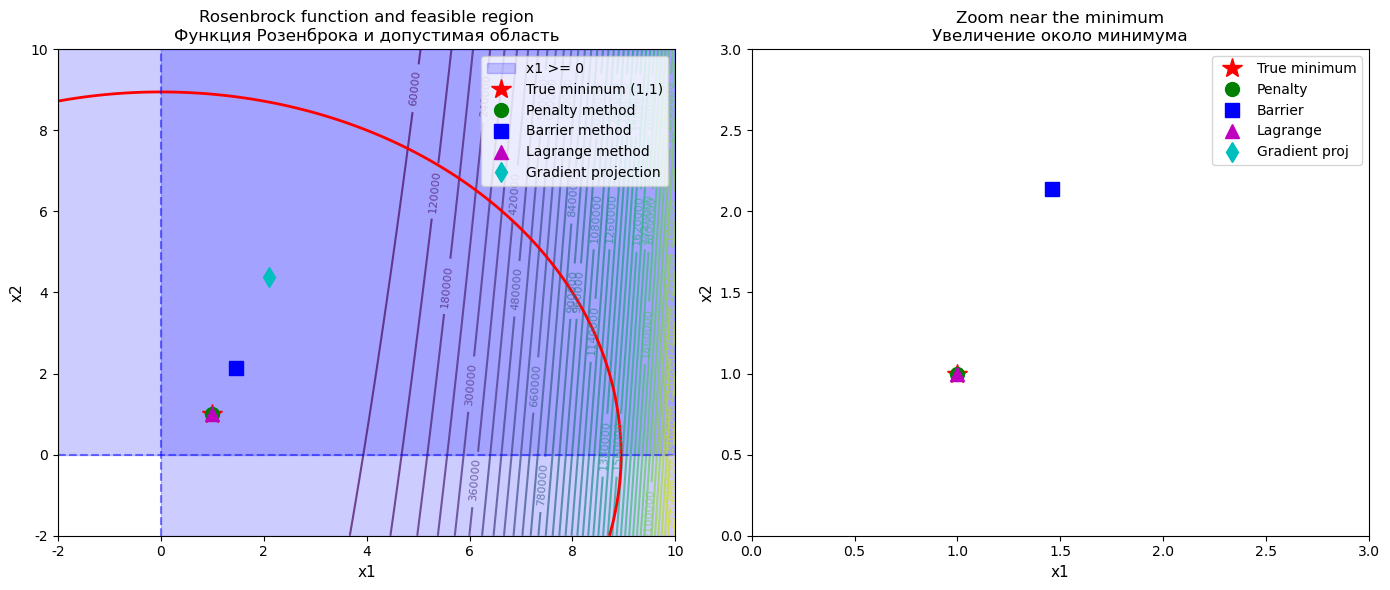


------------------------------------------------------------
РЕЗУЛЬТАТЫ МЕТОДОВ / METHOD RESULTS
------------------------------------------------------------
Method                                 x1              x2            f(x)
---------------------------------------------------------------------------
Penalty function                 0.999994        0.999989   50.0000000001
Barrier function                 1.460782        2.134703   50.4248077493
Lagrange multipliers             0.999994        0.999989   50.0000000001
Gradient projection              2.092305        4.379596   52.3871215562
---------------------------------------------------------------------------
True minimum                     1.000000        1.000000   50.0000000000

✓ Визуализация завершена
✓ Visualization completed


In [7]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ ДОПУСТИМОЙ ОБЛАСТИ И КОНВЕРГЕНЦИИ
# VISUALIZATION OF FEASIBLE REGION AND CONVERGENCE
# ============================================================================

print("=" * 60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("VISUALIZATION OF RESULTS")
print("=" * 60)

# Создаем сетку для контурного графика
x1 = np.linspace(-2, 10, 200)
x2 = np.linspace(-2, 10, 200)
X1, X2 = np.meshgrid(x1, x2)

# Вычисляем функцию Розенброка
Z = np.zeros_like(X1)
for i in range(len(x1)):
    for j in range(len(x2)):
        Z[j, i] = rosenbrock([X1[j, i], X2[j, i]])

# Вычисляем ограничения / Compute constraints
circle_constraint = X1**2 + X2**2 - 80

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Левый график: Контурный график функции и допустимая область
ax1 = ax[0]
contour = ax1.contour(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)
ax1.clabel(contour, inline=True, fontsize=8)
ax1.contour(X1, X2, circle_constraint, levels=[0], colors='red', linewidths=2, label='x1^2 + x2^2 = 80')
ax1.fill_between(x1, 0, 10, alpha=0.2, color='blue', label='x1 >= 0')
ax1.fill_betweenx(x2, 0, 10, alpha=0.2, color='blue')
ax1.set_xlim(-2, 10)
ax1.set_ylim(-2, 10)
ax1.set_xlabel('x1', fontsize=11)
ax1.set_ylabel('x2', fontsize=11)
ax1.set_title('Rosenbrock function and feasible region\nФункция Розенброка и допустимая область', fontsize=12)
ax1.axhline(0, color='blue', linestyle='--', alpha=0.5)
ax1.axvline(0, color='blue', linestyle='--', alpha=0.5)

# Добавляем найденные точки
ax1.plot(1, 1, 'r*', markersize=15, label='True minimum (1,1)')
ax1.plot(x_penalty[0], x_penalty[1], 'go', markersize=10, label='Penalty method')
ax1.plot(x_barrier[0], x_barrier[1], 'bs', markersize=10, label='Barrier method')
ax1.plot(x_lagrange[0], x_lagrange[1], 'm^', markersize=10, label='Lagrange method')
ax1.plot(x_gradproj[0], x_gradproj[1], 'cd', markersize=10, label='Gradient projection')
ax1.legend(loc='upper right')

# Правый график: Близкий вид вокруг минимума
ax2 = ax[1]
ax2.contour(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)
ax2.contour(X1, X2, circle_constraint, levels=[0], colors='red', linewidths=2)
ax2.set_xlim(0, 3)
ax2.set_ylim(0, 3)
ax2.set_xlabel('x1', fontsize=11)
ax2.set_ylabel('x2', fontsize=11)
ax2.set_title('Zoom near the minimum\nУвеличение около минимума', fontsize=12)

ax2.plot(1, 1, 'r*', markersize=15, label='True minimum')
ax2.plot(x_penalty[0], x_penalty[1], 'go', markersize=10, label='Penalty')
ax2.plot(x_barrier[0], x_barrier[1], 'bs', markersize=10, label='Barrier')
ax2.plot(x_lagrange[0], x_lagrange[1], 'm^', markersize=10, label='Lagrange')
ax2.plot(x_gradproj[0], x_gradproj[1], 'cd', markersize=10, label='Gradient proj')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Таблица результатов
print("\n" + "-" * 60)
print("РЕЗУЛЬТАТЫ МЕТОДОВ / METHOD RESULTS")
print("-" * 60)
print("{:<28} {:>12} {:>15} {:>15}".format(
    "Method", "x1", "x2", "f(x)"
))
print("-" * 75)
print("{:<28} {:>12.6f} {:>15.6f} {:>15.10f}".format(
    "Penalty function", x_penalty[0], x_penalty[1], f_penalty
))
print("{:<28} {:>12.6f} {:>15.6f} {:>15.10f}".format(
    "Barrier function", x_barrier[0], x_barrier[1], f_barrier
))
print("{:<28} {:>12.6f} {:>15.6f} {:>15.10f}".format(
    "Lagrange multipliers", x_lagrange[0], x_lagrange[1], f_lagrange
))
print("{:<28} {:>12.6f} {:>15.6f} {:>15.10f}".format(
    "Gradient projection", x_gradproj[0], x_gradproj[1], f_gradproj
))
print("-" * 75)
print("{:<28} {:>12.6f} {:>15.6f} {:>15.10f}".format(
    "True minimum", 1.0, 1.0, 50.0
))

print("\n✓ Визуализация завершена")
print("✓ Visualization completed")